图 4-6 (带百分比的对数柱状图) 已生成。


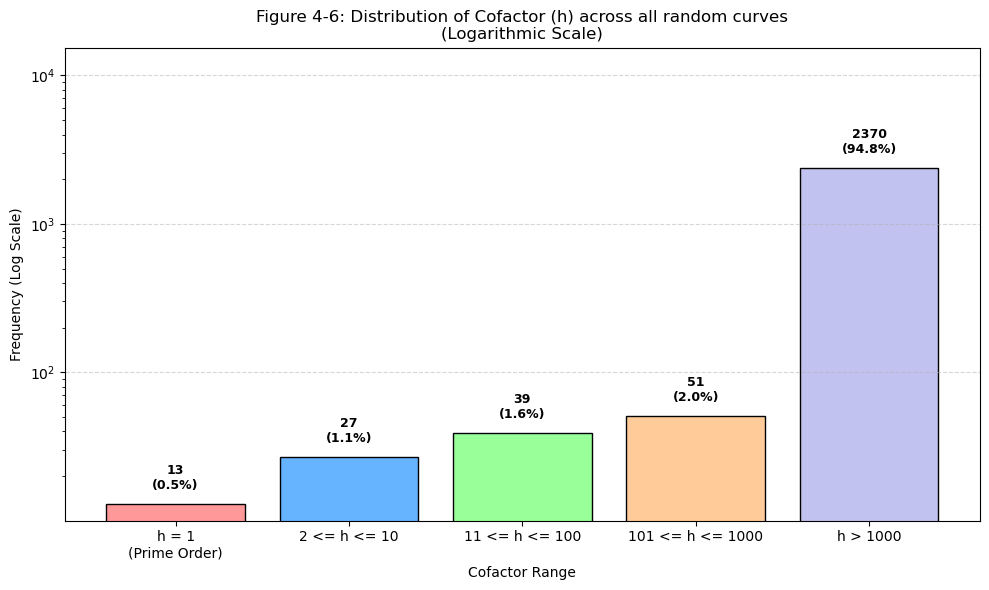

In [1]:
import pickle
import matplotlib.pyplot as plt

with open('ecc_data_merged.pkl', 'rb') as f:
    results = pickle.load(f)

all_h = []
for b in results:
    all_h.extend([d['h'] for d in results[b]])

# 【关键修改 1】：重新划分更合理的区间
ranges = {
    'h = 1\n(Prime Order)': 0,
    '2 <= h <= 10': 0,
    '11 <= h <= 100': 0,
    '101 <= h <= 1000': 0,
    'h > 1000': 0
}

for h in all_h:
    if h == 1:
        ranges['h = 1\n(Prime Order)'] += 1
    elif 2 <= h <= 10:
        ranges['2 <= h <= 10'] += 1
    elif 11 <= h <= 100:
        ranges['11 <= h <= 100'] += 1
    elif 101 <= h <= 1000:
        ranges['101 <= h <= 1000'] += 1
    else:
        ranges['h > 1000'] += 1

labels = list(ranges.keys())
counts = list(ranges.values())

# --- 修复后的图 4-6 绘图与标注代码 ---

plt.figure(figsize=(10, 6)) # 稍微加宽一点图表，让文字有更多空间
bars = plt.bar(labels, counts, color=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'], edgecolor='black')

plt.yscale('log')

# 【关键修改】：计算总样本数，用于算百分比
total_curves = sum(counts)

# 遍历每一个柱子打标签
for bar in bars:
    yval = bar.get_height()
    if yval > 0: # 只有大于0才标注
        # 计算百分比，同样注意转为 float
        pct = (float(yval) / total_curves) * 100
        # 将频数和百分比分两行显示，如 "492\n(98.4%)"
        label_text = f"{int(yval)}\n({pct:.1f}%)"
        
        plt.text(bar.get_x() + bar.get_width()/2.0, yval * 1.2, label_text, 
                 ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.title('Figure 4-6: Distribution of Cofactor (h) across all random curves\n(Logarithmic Scale)')
plt.xlabel('Cofactor Range')
plt.ylabel('Frequency (Log Scale)')

# 扩大 y 轴上限，防止最高的柱子顶部的文字被切掉
ax = plt.gca()
ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax * 5) 

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig4-6_cofactor_bar.png', dpi=300)
print("图 4-6 (带百分比的对数柱状图) 已生成。")